# Motion and Path Generation

This notebook introduces the motion-generation workflow in RobotBlockSet. Its purpose is to show how to generate trajectories and how to construct more complex paths in joint space and task space.


## What this notebook covers

The examples below demonstrate the main trajectory-generation tools, interpolation methods, and path-construction utilities provided by RobotBlockSet, including smooth joint trajectories, Cartesian trajectories, and more complex geometric paths built from multiple segments or orientation changes.

Use this notebook as a practical reference when you want to create motion profiles for robots, compare trajectory types, or prepare paths that will later be tracked by a controller or used in simulation.


# Imports


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

from robotblockset.transformations import *
from robotblockset.tools import gradientPath, gradientCartesianPath
from robotblockset.trajectories import jpoly, jtrap, jline, cpoly, ctrap, cline, ctraj, carctraj, interpPath, interpQuaternionPath, interpCartesianPath, pathoverpoints, pathlen, distance2path, qspline
from robotblockset.graphics import plotcpos_ori, plotucs, plotpathpoints, plotjtraj, plotctraj, plotcpath
from robotblockset.rbf import encodeRBF, decodeCartesianRBF

np.set_printoptions(precision=4, suppress=True)

# Trajectory generation

One the important functionality in robotics toolboxes is generation of paths and trajectories. RBS Toolbox provides tools to generate paths and trajectories in joint and task space. Trajectory generation is based on interpolation. The difference between the interpolation and trajectory generation is that we define the time for the movement from the initial position to the final position and the velocity profile.

## Joint space trajectories

There are three functions for trajectory generation in joint space. 

| Function                                                     | Description                                                  |
| ------------------------------------------------------------ | ------------------------------------------------------------ |
| `[qt,qdt,qddt]=jpoly(q0,q1,t)`,  `[qt,qdt,qddt]=jtraj(q0,q1,t)` | Trajectory based on 5th order polynomial (allows also to select initial and final velocities) |
| `[qt,qdt,qddt]=jtrap(q0,q1,t,ta)`                            | Trajectory with trapezoidal velocity profile                 |
| `[qt,qdt,qddt]=jline(q0,q1,t)`                               | Trajectory with constant velocity                            |

They generate a sequence of interpolated  joint positions, velocities and accelerations for motion from initial configuration `q0` to final configuration `q1` for instances defined by sequence `t`.



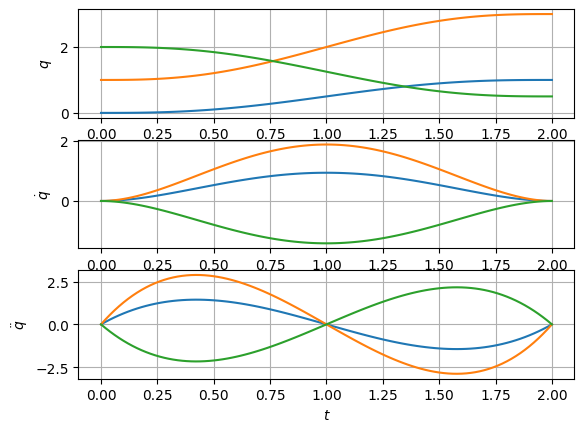

In [3]:
t = np.arange(0, 2.0001, 0.02)
qt, qdt, qddt = jpoly([0, 1, 2], [1, 3, 0.5], t)
_ = plotjtraj(t, qt, qdt, qddt)

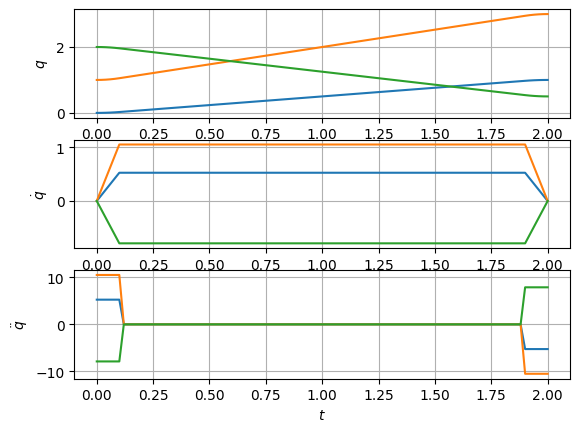

In [4]:
t = np.arange(0, 2.0001, 0.02)
qt, qdt, qddt = jtrap([0, 1, 2], [1, 3, 0.5], t)
_ = plotjtraj(t, qt, qdt, qddt)

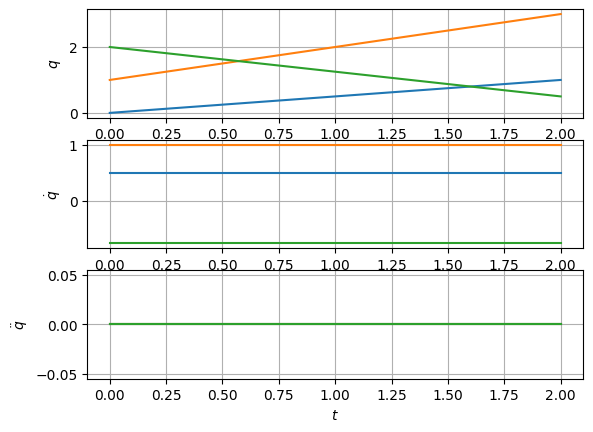

In [5]:
t = np.arange(0, 2.0001, 0.02)
qt, qdt, qddt = jline([0, 1, 2], [1, 3, 0.5], t)
_ = plotjtraj(t, qt, qdt, qddt)

## Task space trajectories

There are three basic functions for trajectory generation in task space. 

| Function                              | Description                                                  |
| ------------------------------------- | ------------------------------------------------------------ |
| `[xt,vt,at]=cpoly(T0,T1,t)`           | Cartesian trajectory based on 5th order polynomial           |
| `[xt,vt,at]=ctrap(T0,T1,t,ta)`        | Cartesian trajectory with trapezotidal velocity profile      |
| `[xt,vt,at]=cline(T0,T1,t)`           | Cartesian trajectory with constant velocity                  |
| `[xt,vt,at]=ctraj(T0,T1,t,fun)`       | Cartesian trajectory with custom velocity profile            |
| `[xt,vt,at]=carctraj(x0,x1,pC,t,fun)` | Cartesian trajectory trajectory for motion on an arc with custom velocity profile |

They generate a sequence of interpolated  positions and orientations, velocities and accelerations for motion from initial pose `x0` to final pose `x1` for instances defined by sequence `t`. All functions use linear interpolation for positions and SLERP for orientations.



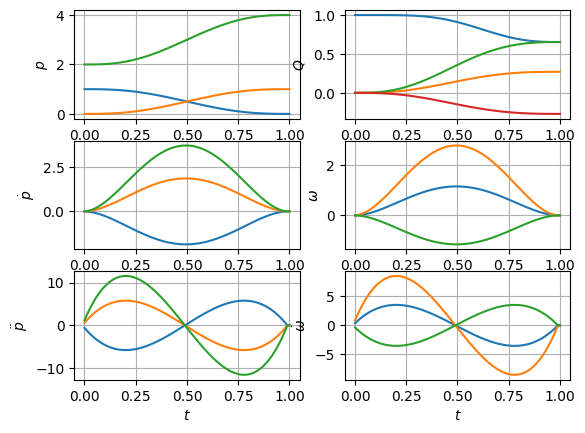

In [6]:
T0 = rp2t(np.eye(3), [1, 0, 2], out="T")
T1 = rp2t(rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R"), [0, 1, 4], out="T")
t = np.arange(0, 1.0001, 0.01)
xt, vt, at = cpoly(t2x(T0), t2x(T1), t)
_ = plotctraj(t, xt, vt, at)

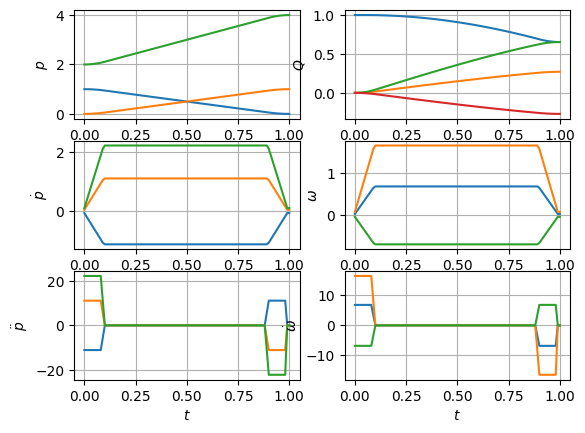

In [7]:
xt, vt, at = ctrap(t2x(T0), t2x(T1), t)
_ = plotctraj(t, xt, vt, at)

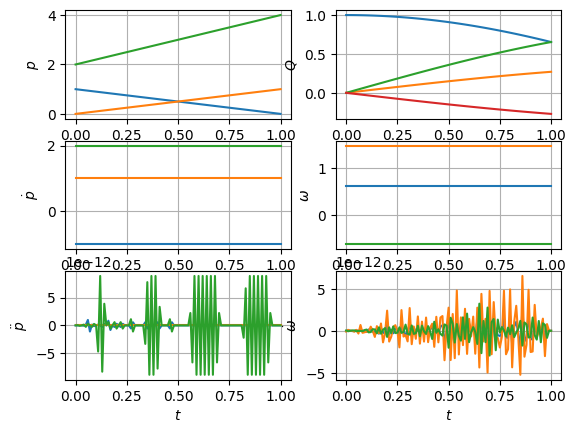

In [8]:
xt, vt, at = cline(t2x(T0), t2x(T1), t)
_ = plotctraj(t, xt, vt, at)

Additionally, there is a function `ctraj(T0,T1,t,fun)`, where the velocity profile can be defined as an input parameter. This allows to define custom function for motion profile. For example

In [9]:
xt, vt, at = cpoly(t2x(T0), t2x(T1), t)
xt, vt, at = ctraj(t2x(T0), t2x(T1), t, traj="poly")



generate the same trajectory.

Using function `carctraj` we can define a trajectory for motion on an arc, where we can select the velocity profile in the same way as for `ctraj`.  



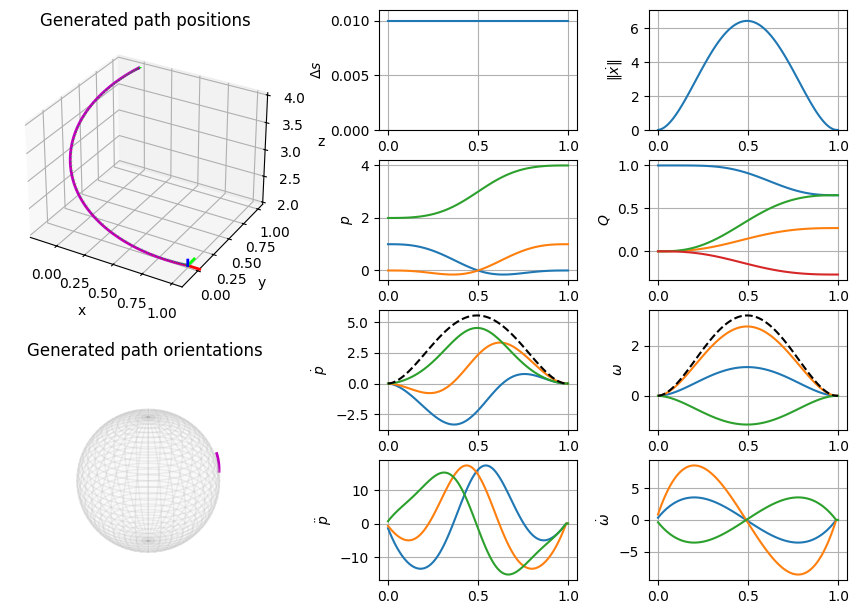

In [10]:
T0 = rp2t(np.eye(3), [1, 0, 2], out="T")
T1 = rp2t(rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R"), [0, 1, 4], out="T")
pC = [1, 1, 3]
t = np.arange(0, 1.0001, 0.01)
xt, vt, at = carctraj(t2x(T0), t2x(T1), pC, t)
_ = plotcpath(t, xt)

# Path generation and interpolation

With the trajectory generation functions we can generate motion between two positions, where the motion starts in the initial position and stops in the final position, i.e. initial and final velocities are 0. To generate a more complex motion, like continuous motion over or near many points, RBS Toolbox provides several functions to work with paths

| Function                                  | Description                                                  |
| ----------------------------------------- | ------------------------------------------------------------ |
| `xnew=interpPath(s,x,snew)`               | Interpolate path for query path values                       |
| `xnew=interpCartesianPath(s,x,snew)`      | Interpolate Cartesian path for query path values             |
| `xnew=interpQuaternionPath(s,Q,snew)`     | Interpolate quaternion path for query path values            |
| `x=uniqueCartesianPath(x)`                | Correct the quaternions in cartesian path so that they are unique (dot product of consecutive quaternions is positive) |
| `Q=uniqueQuaternionPath(Q)`               | Correct the quaternion  path so that they are unique (dot product of consecutive quaternions is positive) |
| `[xi,si]=pathoverpoints(points,...)`      | Generates path over points using spline interpolation        |
| `auxpnt=pathauxpointspoints(points,...)`  | Generates auxiliary points for path points                   |
| `[send,si]=pathlen(path,scale)`           | Calculates path length using positions or orientations or both |
| `[px,d]=distance2line(p0,p,dir)`          | Find the closest point on line and calculate distance        |
| `[px,d,sx]=distance2path(x,path,s,scale)` | Find the closest point on path and calculate distance        |
| `qout=qspline(q,s,mode)`                  | Spline interpolation of quaternions in spherical space       |
| `xd=gradientPath(x,t)`                    | Calculate derivative along path                              |
| `xd=gradientCartesianPath(x,t)`           | Calculate derivative along Cartesian path                    |
| `Qd=gradientQuaternionPath(Q,t)`          | Calculate gradient along quaternion path                     |

## Path interpolation

Path interpolation can be done for joint and task space paths. In case of joint space paths, we use function `interpPath`, which is a wrapping function for standard linear interpolation.



In [11]:
qpath = np.array([[1, 0, 2, -1], [2, 1, 2, 3], [0, 3, -2, 2]], dtype=float)
s = np.arange(1, 4)
si = np.linspace(1, 3, 6)
qi = interpPath(s, qpath, si)
print(qi)

[[ 1.   0.   2.  -1. ]
 [ 1.4  0.4  2.   0.6]
 [ 1.8  0.8  2.   2.2]
 [ 1.6  1.4  1.2  2.8]
 [ 0.8  2.2 -0.4  2.4]
 [ 0.   3.  -2.   2. ]]


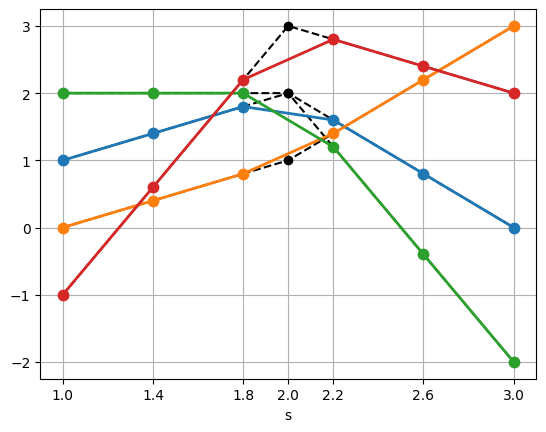

In [12]:
plt.figure(1)
plt.plot(s, qpath, "ko--")
plt.plot(si, qi, ".-", linewidth=2, markersize=15)
plt.grid(True)
plt.xticks(np.union1d(s, si))
_ = plt.xlabel("s")

Path interpolation for quaternion paths is wrapper for SLERP interpolation.



In [13]:
q = np.array(
    [
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.7071, 0.0000, 0.7071, 0.0000],
        [0.0000, 1.0000, -0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
    ]
)
s = np.arange(1, 5)
si = np.linspace(1, 4, 9)
qi = interpQuaternionPath(s, q, si)
print(qi)

[[1.     0.     0.     0.    ]
 [0.9569 0.     0.2903 0.    ]
 [0.8315 0.     0.5556 0.    ]
 [0.6935 0.1951 0.6935 0.    ]
 [0.5    0.7071 0.5    0.    ]
 [0.1379 0.9808 0.1379 0.    ]
 [0.3827 0.9239 0.     0.    ]
 [0.8315 0.5556 0.     0.    ]
 [1.     0.     0.     0.    ]]


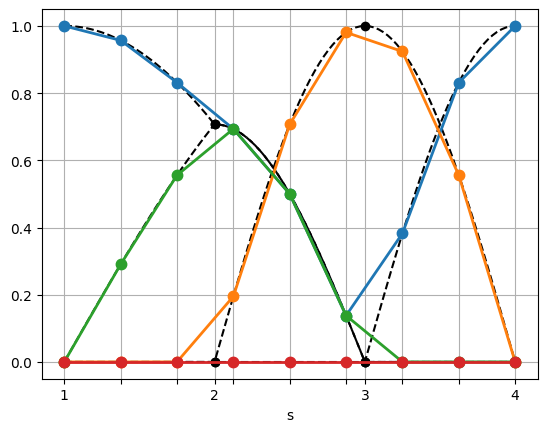

In [14]:
ssi = np.linspace(1, 4, 100)
qqi = interpQuaternionPath(s, q, ssi)

plt.figure(2)
plt.plot(s, q, "ko")
plt.plot(ssi, qqi, "k--")
plt.plot(si, qi, ".-", linewidth=2, markersize=15)
plt.grid(True)
plt.xticks(np.union1d(s, si), ["1", "", "", "2", "", "", "", "3", "", "", "4"])
_ = plt.xlabel("s")

Cartesian path interpolation is a combination of linear interpolation for positions and SPLINE interpolation.



In [15]:
x = np.array(
    [
        [1, 0, 0, 1.0000, 0.0000, 0.0000, 0.0000],
        [2, -1, 2, 0.7071, 0.0000, 0.7071, 0.0000],
        [4, 3, 2, 0.0000, 1.0000, -0.0000, 0.0000],
        [3, 3, 0, 1.0000, 0.0000, 0.0000, 0.0000],
    ]
)
s = np.arange(1, 5)
si = np.linspace(1, 4, 100)
xi = interpCartesianPath(s, x, si)

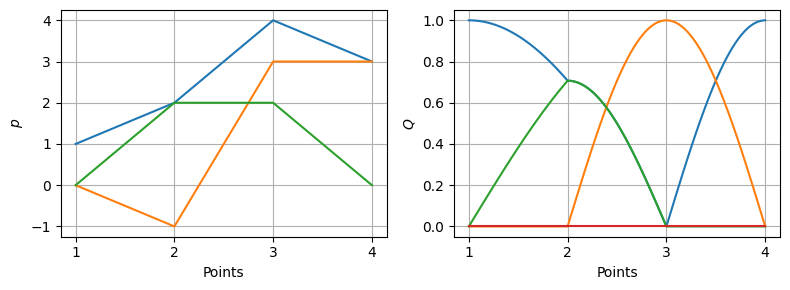

In [16]:
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(8, 3))
plotcpos_ori(si, xi, graph="time", typ="Pos", ax=axes[0])
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xlabel("Points")
axes[0].grid(True)
plotcpos_ori(si, xi, graph="time", typ="Ori", ax=axes[1])
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xlabel("Points")
axes[1].grid(True)
plt.tight_layout()

## Path gradient and derivatives

To calculate gradient along the path use functions `gradientPath` for  joint space paths and for pure position paths in task space. If orientations are included use `gradientQuaternionPath` or `gradientCartesianPath`. 

Velocities can be calculated if the independent variable is time, i.e. we generate a trajectory. For that, the independent variables (`s` and `t` in the example)  must have the same initial and final value. 



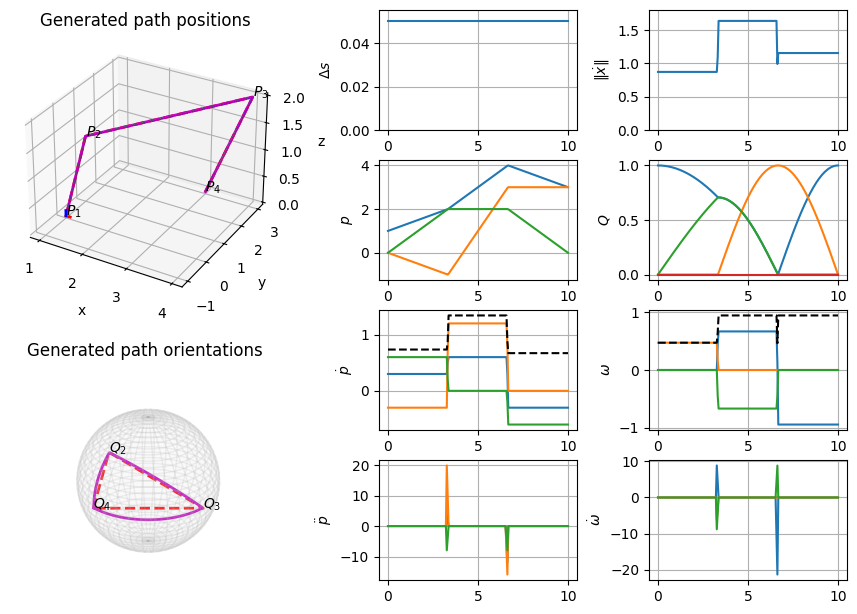

In [17]:
x = np.array(
    [
        [1, 0, 0, 1.0000, 0.0000, 0.0000, 0.0000],
        [2, -1, 2, 0.7071, 0.0000, 0.7071, 0.0000],
        [4, 3, 2, 0.0000, 1.0000, -0.0000, 0.0000],
        [3, 3, 0, 1.0000, 0.0000, 0.0000, 0.0000],
    ]
)
tmax = 10
s = np.linspace(0, tmax, 4)
t = np.linspace(0, tmax, 200)
xt = interpCartesianPath(s, x, t)
vt = gradientCartesianPath(xt, t)
at = gradientPath(vt, t)
hx, ax = plotcpath(t, xt, points=x, ori_sel=[1, 2])
ax[1].view_init(elev=30, azim=45)



![](README.assets/gradientCartesianPath_1.png)

> Note that for the calculation of path acceleration, we always use `gradientPath`  as rotational velocities form a vector space.

## Unique quaternion paths

Because $Q=-Q$, there are always two quaternions representing the same orientation. Therefore, when a task-space paths are represented using quaternions it may happen that the quaternions are switching along path form one solution to another. This may cause problems. To change the path representations so that quaternions are using unique solution for representing orientations, RBS Toolbox provides two functions `uniqueQuaternionPath(Q)` and `uniqueCartesianPath(x)` that make quaternions unique, i.e. they change sequence of quaternions in such a way, that the dot product between two consecutive  quaternions keeps the sign.  



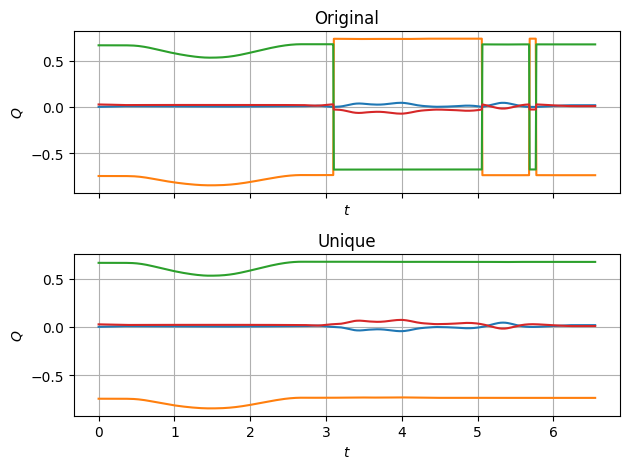

In [18]:
data = loadmat("assets/sample_traj.mat")
cart_traj = data["cart_traj"]
time = data["time"].squeeze()

fig, axes = plt.subplots(2, 1, sharex=True)
plotcpos_ori(time, cart_traj, graph="time", typ="Ori", ax=axes[0])
axes[0].set_title("Original")
cart_traj_u = uniqueCartesianPath(cart_traj)
plotcpos_ori(time, cart_traj_u, graph="time", typ="Ori", ax=axes[1])
axes[1].set_title("Unique")
plt.tight_layout()

## Path via multiple points

Using function `pathoverpoints`  we can generate smooth trajectories from the initial point via or near intermediate points to the final point. This function has several options defining the path generation.

| Option      | Values                                   | Description                                                  |
| ----------- | ---------------------------------------- | ------------------------------------------------------------ |
| `interp`    | **`'inner'`**, `'spline'`, `'RBF'`, `'none'`      | Interpolation type: <br>`'inner'`     spline by uniform subdivision <br>`'spline'`    cubic spline curve <br>`'none'`      no interpolation |
| `step`      | 0.01                                     | Maximal difference in path parameter                         |
| `n_points`  | 0                                        | Minimal number of path points - if 0 then Step is used       |
| `auxpoints` | `'absolute'`, `'relative'`, **`'none'`** | Auxiliary points: <br>`'absolute'`  Auxdist parameter is absolute distance <br> `'relative'`  Auxdist parameter is relative segment distance<br> `'none'`          No Auxpoints |
| `auxdist`   | [0.1 0.2]                                | distance of auxiliary points `[position orientation]`        |
| `order`     | 4                                        | Order of inner spline (>=3)                                  |
| `natural`   | `'on'`, **`'off'`**                      | Make path parameter natural (=path distance)                 |
| `normscale` | 0                                        | Scaling factor for rotation norm                             |
| `plot`      | `'on'`, **`'off'`**                      | Generate plots                                               |
| `ori_sel`   | [1, 2]                                   | Figure handle                                                |

*Defualts are in bold.

For example, let generate a smooth path over the following points



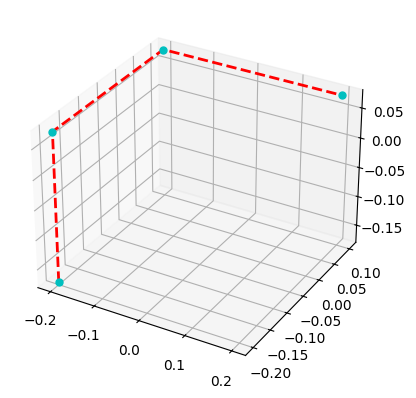

In [19]:
pte = np.array(
    [
        [-0.2, -0.2, -0.175, 0, 0, 0],
        [-0.2, -0.2, 0.075, 0, 0, -np.pi / 2],
        [-0.2, 0.1, 0.075, -np.pi / 2, 0, -np.pi / 2],
        [0.2, 0.1, 0.075, -np.pi, 0, -np.pi / 2],
    ]
)
pt = prpy2x(pte)
_ = plotpathpoints(
    pt,
)

By changing the options we get different paths. First, we generate a path using `'inner'` spline with `'Order'=4` without auxiliary points



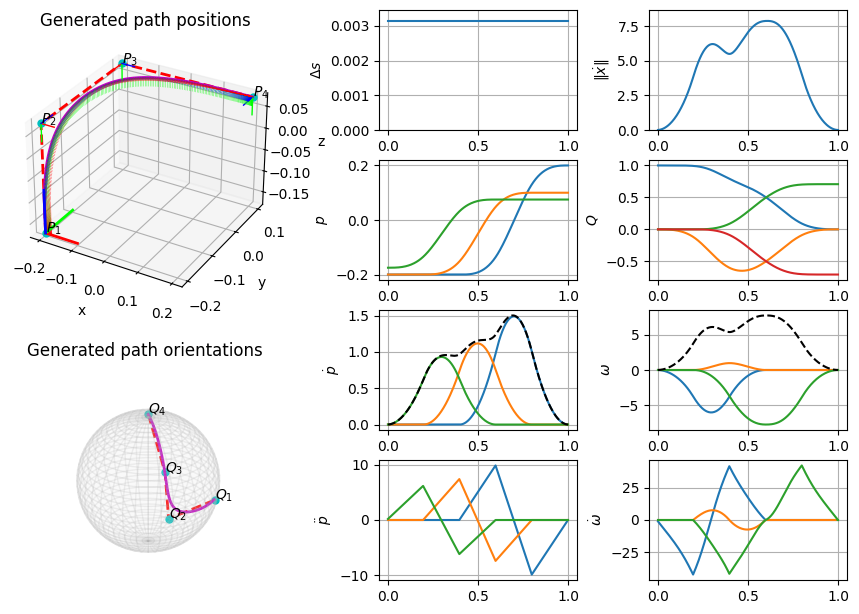

In [20]:
xi, si = pathoverpoints(pt, step=0.01, order=4, plot=True)

The generated path does not go over intermediate points, but approaches them (how close depends on parameter `'Order'`). 

Note that the generated accelerations are not smooth. By increasing interpolation order, the generated path becomes smoother, but also the distance to intermediate points is greater. 

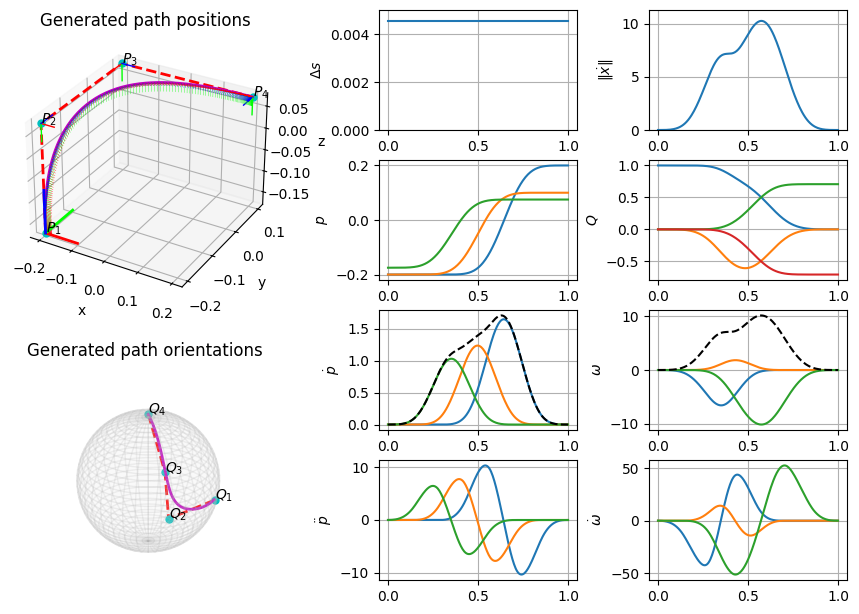

In [21]:
xi, si = pathoverpoints(pt, step=0.01, order=6, plot=True)

If we want that the path goes closer to the intermediate points, we can add auxiliary points. In this case we have added relative auxiliary points for position and rotation.

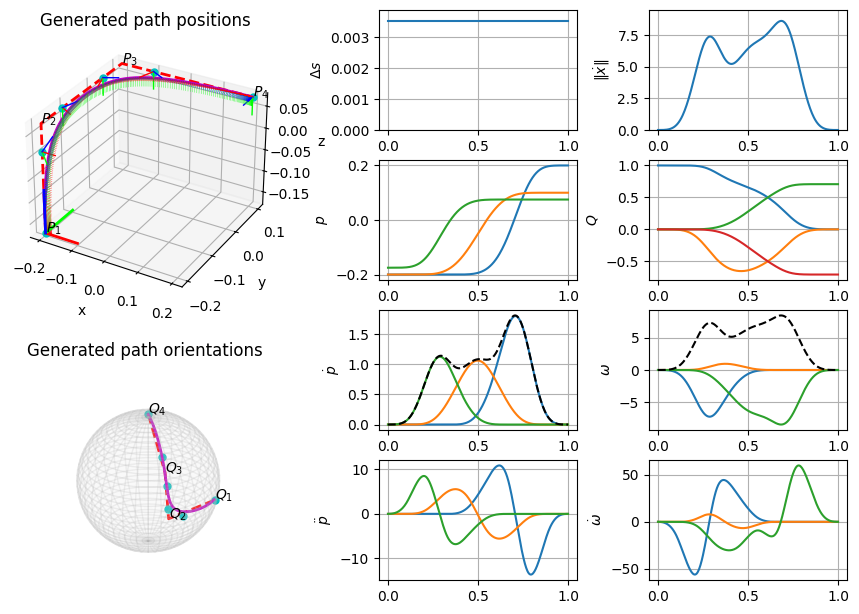

In [22]:
xi, si = pathoverpoints(pt, step=0.01, order=6, auxpoints="relative", auxdistance=0.25, plot=True)

In this case we have added only auxiliary points for position, rotation in these auxiliary points is as  on the other side of a segment where the auxiliary position point is added.

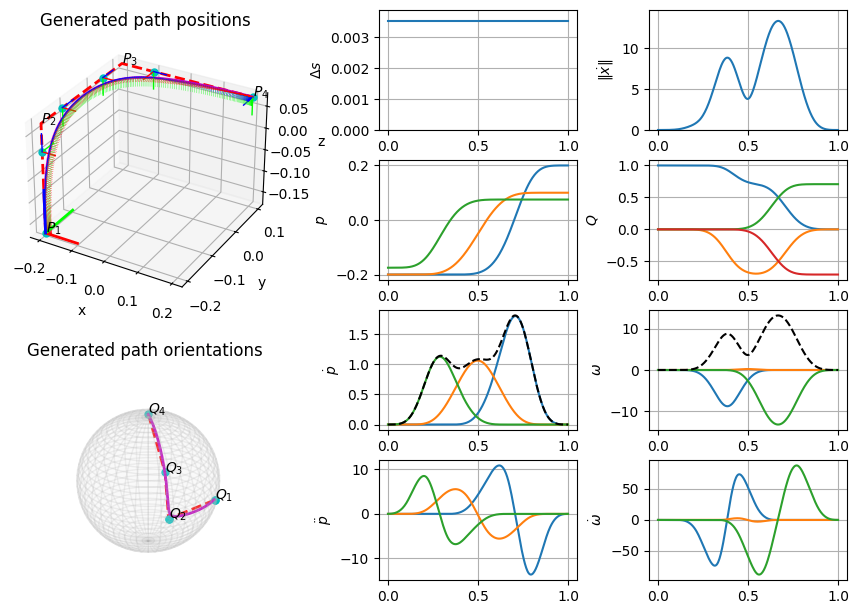

In [23]:
xi, si = pathoverpoints(pt, step=0.01, order=6, auxpoints="relative", auxdistance=[0.25, 0], plot=True)

Using function `pathauxpoints`  the generation is almost the same, except that this function has an additional option `'viapoints'`, which allows to use for path generation only auxiliary points, while the intermediate points (via) points are neglected.

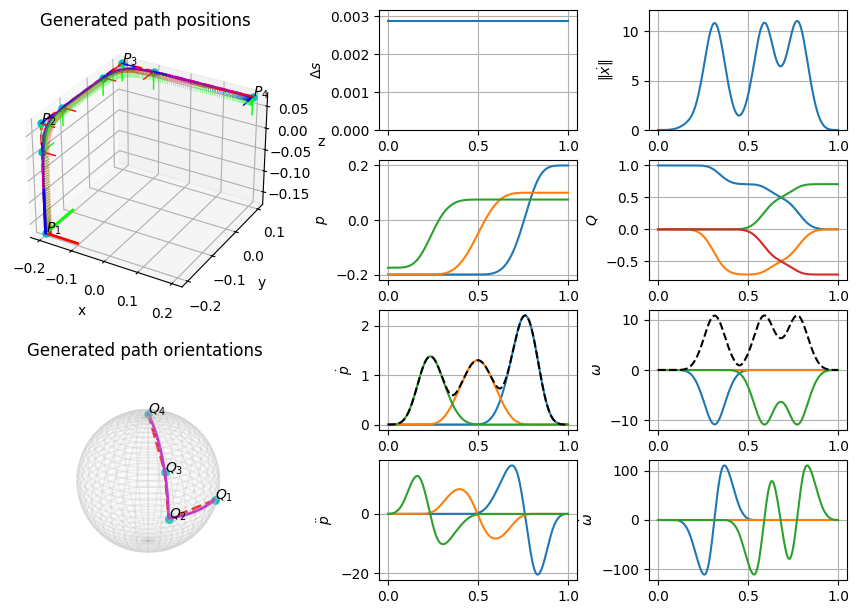

In [24]:
xi, si = pathoverpoints(pt, step=0.01, order=6, auxpoints="relative", auxdistance=[0.25, 0], viapoints=True, plot=True)

On the other hand, using `'spline'` interpolation the generated path passes the intermediate points

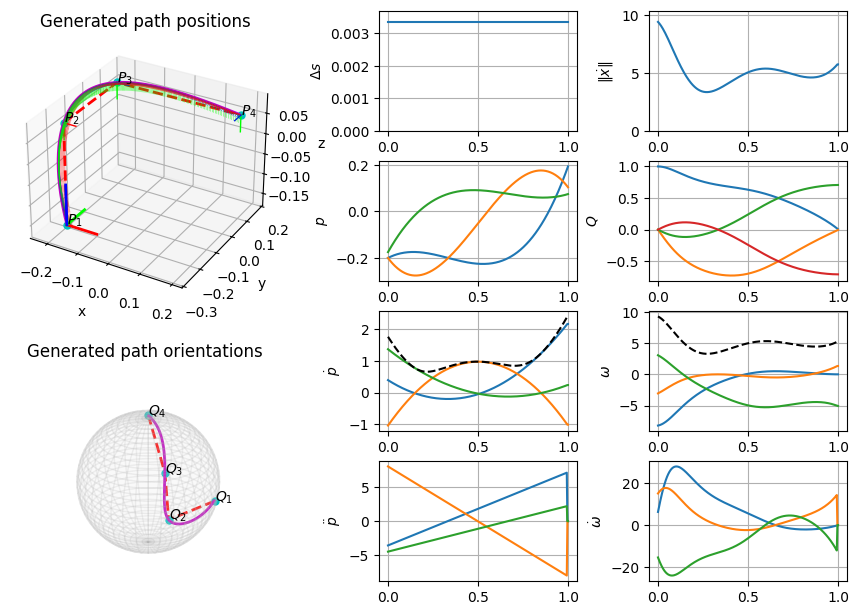

In [25]:
xi, si = pathoverpoints(pt, step=0.01, interp="spline", plot=True)

We can use RBF parametrization path generation over multiple points. Compared to spline interpolation, we can also define here the initial and final conditions for velocity and acceleration.


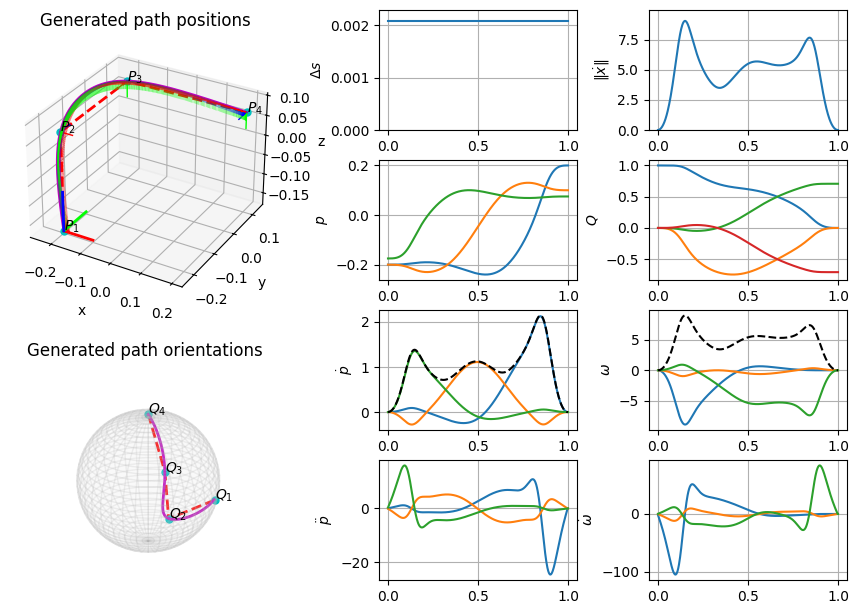

In [26]:
xi, si = pathoverpoints(pt, step=0.01, interp="RBF", plot=True)

Until now the path samples have been equidistantly distributed over the whole path with `s=0` at start and `s=1` in the final point. Consequently, we can observe that changes between samples (velocities $\|\dot x\|$) were not constant. Selection option `natural=True` the path parameter is defined by the path length
$$
s(k) = \sum_{i=2}^k \sqrt{\|p_{k}-p_{k-1}\|^2+a^2 \|2\log(Q_k*Q_{k-1}^{-1})\|^2}
$$
where $p_k$ are the positions and $Q_k$ the orientations of generated path points. Parameter $a$ is the scaling factor `normscal`.  Using natural path parameter assures that  weighted norm $\|\dot x\|_a=1$.

For our example, a good choice is `For a=0.1`.

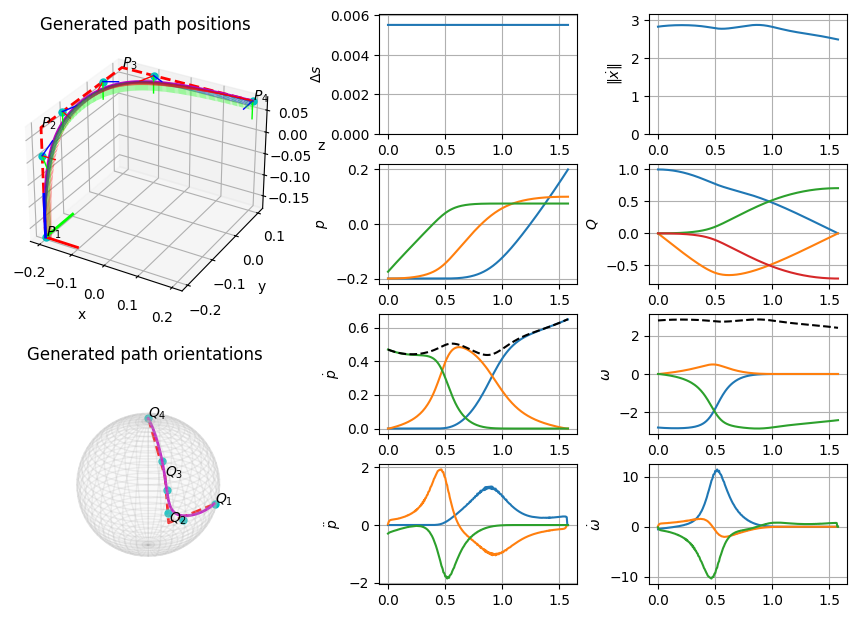

In [27]:
xi, si = pathoverpoints(pt, step=0.01, natural=True, normscale=[1, 0.1], order=6, auxpoints="relative", auxdistance=0.25, plot=True)

## Orientation interpolation

Note that in function `pathoverpoints` the interpolation of orientation is not based on SLERP. If for some reason a specific interpolation of orientation is required, then it is better to use function `qspline`, which allows two types of interpolation

| Parameter | Values                       | Comment                                                      |
| --------- | ---------------------------- | ------------------------------------------------------------ |
| `mode`    | `'hermite_cubic'`, `'squad'` | `'hermite_cubic'` cubic curve using Bezier-Bernstein basis `'squad'`  spherical and quaternion angle interpolation. Analogous to bilinear interpolation in euclidean space. |

The differences between different interpolation methods for quaternioms are seen in the following example



In [28]:
q = np.array(
    [
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.7071, 0.0000, 0.7071, 0.0000],
        [0.0000, 1.0000, -0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
    ]
)
s = np.arange(0, 4)
si = np.linspace(0, 3, 9)
qi = interpQuaternionPath(s, q, si)
print(qi)

[[1.     0.     0.     0.    ]
 [0.9569 0.     0.2903 0.    ]
 [0.8315 0.     0.5556 0.    ]
 [0.6935 0.1951 0.6935 0.    ]
 [0.5    0.7071 0.5    0.    ]
 [0.1379 0.9808 0.1379 0.    ]
 [0.3827 0.9239 0.     0.    ]
 [0.8315 0.5556 0.     0.    ]
 [1.     0.     0.     0.    ]]


In [29]:
xi, si = pathoverpoints(np.hstack((np.zeros((4, 3)), q)), interp="spline")
q_slerp=interpQuaternionPath(s / s[-1],q,si)
q_spline = xi[:, 3:]
q_squad = qspline(q, si, "squad")
q_hermite = qspline(q, si, "hermite_cubic")

In [30]:
# # Assumes q, s, t, q_slerp, q_spline, q_squad, q_hermite, ti are defined
# t = si.copy()
# n = q.shape[0]
# tt = t * (n - 1) + 1

# fig = plt.figure(4)
# fig.clf()
# fig.set_size_inches(9, 6)
# gs = fig.add_gridspec(3, 2)
# ax3d = fig.add_subplot(gs[:, 0], projection="3d")
# ax_q = fig.add_subplot(gs[0, 1])
# ax_w = fig.add_subplot(gs[1, 1])
# ax_dw = fig.add_subplot(gs[2, 1])

# plotcpos_ori(s, Q=q, graph="3D", typ="Ori", ax=ax3d, label=True, alpha=0.9)
# h1, _ = plotcpos_ori(t, Q=q_slerp, graph="3D", typ="Ori", ax=ax3d, UCS=True)
# h2, _ = plotcpos_ori(t, Q=q_spline, graph="3D", typ="Ori", ax=ax3d, UCS=True)
# h3, _ = plotcpos_ori(t, Q=q_squad, graph="3D", typ="Ori", ax=ax3d, UCS=True)
# h4, _ = plotcpos_ori(t, Q=q_hermite, graph="3D", typ="Ori", ax=ax3d, UCS=True)
# ax3d.view_init(12, 123)
# ax3d.legend([h1[0][0], h2[0][0], h3[0][0], h4[0][0]], ["Slerp", "Spline", "Squad", "Hermite"])

# plotcpos_ori(tt, Q=q_slerp, typ="Ori", ax=ax_q)
# plotcpos_ori(tt, Q=q_spline, typ="Ori", ax=ax_q)
# plotcpos_ori(tt, Q=q_squad, typ="Ori", ax=ax_q)
# plotcpos_ori(tt, Q=q_hermite, typ="Ori", ax=ax_q)
# ax_q.plot(np.arange(1, n + 1), q, "k.", markersize=10)
# ax_q.set_xticks(np.arange(1, n + 1))
# ax_q.set_xlabel("point")
# ax_q.set_ylabel("Q")

# vqt = gradientQuaternionPath(q_slerp, t)
# vqt1 = gradientQuaternionPath(q_spline, ti)
# vqt2 = gradientQuaternionPath(q_squad, t)
# vqt3 = gradientQuaternionPath(q_hermite, t)
# ax_w.plot(tt, vqt, "k-")
# ax_w.plot(tt, vqt1, "b-")
# ax_w.plot(tt, vqt2, "r-")
# ax_w.plot(tt, vqt3, "g-")
# ax_w.set_xticks(np.arange(1, n + 1))
# ax_w.set_xlabel("point")
# ax_w.set_ylabel("omega")
# ax_w.grid(True)

# # aqt = gradientPath(vqt, t)
# # aqt1 = gradientPath(vqt1, ti)
# # aqt2 = gradientPath(vqt2, t)
# # aqt3 = gradientPath(vqt3, t)
# # ax_dw.plot(tt, aqt * 0, "k-")
# # ax_dw.plot(tt * (n - 1) + 1, aqt1, "b-")
# # ax_dw.plot(tt, aqt2, "r-")
# # ax_dw.plot(tt, aqt3, "g-")
# # ax_dw.set_xticks(np.arange(1, n + 1))
# # ax_dw.set_xlabel("point")
# # ax_dw.set_ylabel("dot omega")
# # ax_dw.grid(True)



![](README.assets/qspline_1.png)



## Path utilities

Utility functions  are used to get some information about paths like path length or distance to path. The path length is calculated as a weighted sum of distances between path points 
$$
s(k) = \sum_{i=2}^k \sqrt{s_p\|p_{k}-p_{k-1}\|^2+s_Q\|2\log(Q_k*Q_{k-1}^{-1})\|^2}
$$
where $p_k$ are the positions and $Q_k$ the orientations of generated path points, and $s_p$ and $s_Q$ are weights for position and orientation distances. 



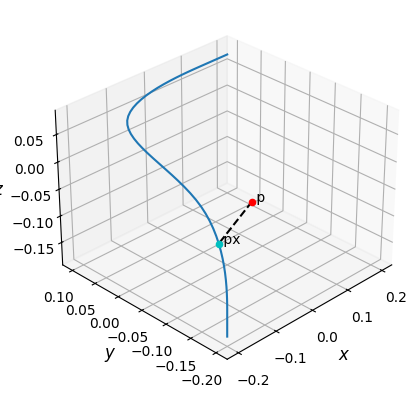

In [31]:
pte = np.array(
    [
        [-0.2, -0.2, -0.175, 0, 0, 0],
        [-0.2, -0.2, 0.075, 0, 0, -np.pi / 2],
        [-0.2, 0.1, 0.075, -np.pi / 2, 0, -np.pi / 2],
        [0.2, 0.1, 0.075, -np.pi, 0, -np.pi / 2],
    ]
)
pt = prpy2x(pte)
path, si = pathoverpoints(pt, n_points=51)
s = np.linspace(0, 1, path.shape[0])
length = pathlen(path, [1, 0])
p = np.array([0, -0.1, -0.05])
px, d, sx = distance2path(p, path[:, :3], s)
hx, ax = plotcpos_ori(s, path, typ="Pos", graph="3D")
ax.view_init(elev=30, azim=-135)
ax.scatter(p[0], p[1], p[2], color="r")
ax.text(p[0], p[1], p[2], " p")
ax.scatter(px[0], px[1], px[2], color="c")
ax.text(px[0], px[1], px[2], " px")
_ = ax.plot([p[0], px[0]], [p[1], px[1]], [p[2], px[2]], "k--")

Considering also orientations the distance is defined as 
$$
d=\sqrt{s_p\|p_e\|^2+s_Q\|Q_e\|^2}
$$
where $p_e$ and $Q_e$ are position and orientation errors between the point `p` and a point on path `px`, and $s$ is a weighting factor for orientatios.



In [32]:
p

array([ 0.  , -0.1 , -0.05])

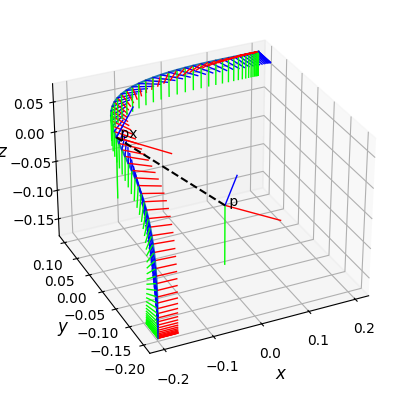

In [33]:
p = map_pose(p=[0, -0.1, -0.05], RPY=[-np.pi / 4, 0, -np.pi / 2])
px, d, sx = distance2path(p, path, s, [1, 0.1])
_, ax = plotcpos_ori(s, path, typ="Pos", graph="3D", UCS=True)
ax.view_init(elev=30, azim=-115)
_, ax =plotucs(p, UCS_length=0.1)
ax.text(p[0], p[1], p[2], " p")
_, ax =plotucs(px, UCS_length=0.1)
ax.text(px[0], px[1], px[2], " px")
_ = plt.plot([p[0], px[0]], [p[1], px[1]], [p[2], px[2]], "k--")

# Path approximations

## Radial basis function (RBF)

If a path or trajectory is obtained by capturing motion of a robot, e.q. by using kinestetic guidance, it is  possible to approximate the captured path by using radial basis functions (RBF). Among many possible radial basis functions we have selected ones with Gaussian kernels defined as
$$
\Psi(x) =  e^{ -\frac{(x  - c)^2}{2 \sigma}}
$$
which is centred at $c$ and $h$ is defining the width of the kernel function. An important feature of this kernel function is that it expresses $\mathcal{C}^\infty$ continuity. 

The approximation function $f$ of captured data $\mathbf{y}$ can be defined as a linear combination of weighted radial basis functions. We use a normalized version of this function, which yields
$$
f(x) =\frac{ \sum_{j=1}^m w_{j}\Psi_j(x)}{ \sum_{j=1}^m\Psi_j(x)}
$$
where $m$ is the number of kernel functions. The kernel functions are centred at $c_i$. Using $\mathbf{\Phi}$ defined as a row vector with components 
$$
\mathbf{\Phi}_k(x) = \frac{\Psi_k(x)}{\sum_{j=1}^m\Psi_j(x)}
$$
yields
$$
f(x) = \mathbf{\Phi}(x) \mathbf{w}
$$
where $\mathbf{w}$ is a vector with elements $w_j$. Applying this to the given data set of points we obtain a set of linear independent equations
$$
\mathbf{A} \mathbf{w} = \mathbf{y}
$$
where $\mathbf{y}$ is a vector of captured data with elements $y_i$, and $\mathbf{A}$ is a matrix with rows $\mathbf{\Phi}(x_i)$. The corresponding weights $\mathbf{w}$ can be found as
$$
\mathbf{w} =\mathbf{A}^{-1} \mathbf{y}
$$

The functions to work with RBF approximations are

| Function                                             | Description                                                  |
| ---------------------------------------------------- | ------------------------------------------------------------ |
| `RBF = encodeRBF(x,y,N,c,sigma2,bc,coff,sfac)`       | Calculate weights for Gaussian radial basis functions optionally allowing also specification of initial and final velocities and accelerations |
| `y, ydot, yddot, ydddot = decodeRBF(x,RBF)`          | Calculate path in point x using Gaussian radial basis functions |
| `x, v, a = decodeCartesianRBF(x,RBF)`                | Calculate Cartesian path in point x using Gaussian radial basis functions |
| `q, w, wdot = decodeQuaternionRBF(x,RBF)`            | Calculate quaternion path in point x using Gaussian radial basis functions |
| `J, Jdot = jacobiRBF(x,RBF)`                         | Calculates the Jacobian and its derivative using numeric differentiation |
| `y, RBF = updateRBF(x,y,RBF)`                        | Update weights for (RBF) using recursive regression          |

The RBF encoding for quaternion data is done for each component independently, but RBF decoding assures that returned quaternions are unit quaternions. 

For example, captured Cartesian path of a robot end-effector can be approximated using RBF using `encodeRBF` and `decodeCartesianRBF` functions



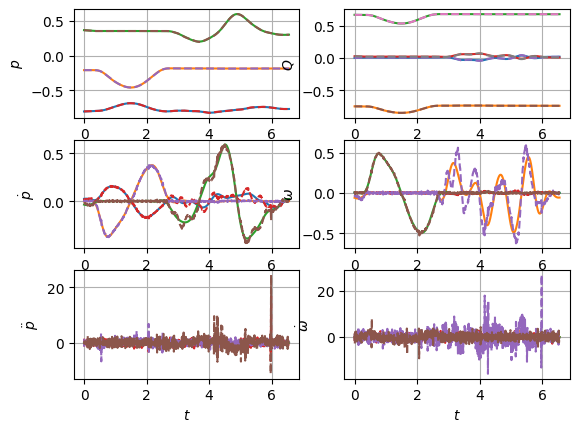

In [34]:
data = loadmat("assets/sample_traj.mat")
cart_traj = data["cart_traj"]
time = data["time"].squeeze()
x = uniqueCartesianPath(cart_traj)
RBF = encodeRBF(time, x, N=25)
x_rbf = decodeCartesianRBF(time, RBF)
_, ax = plotctraj(time, x_rbf)
_ = plotctraj(time, x, ax=ax, linestyle='dashed')
